In [1]:
import os
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report

### Helper functions

In [28]:
def map_stages(stage):
	"""
	Map stages, merging stages 3 and 4 into 3_4.
	"""
	if stage in {3, 4}:
		return '3_4'
	return str(stage)

# Function to create a mapping dictionary
def create_mapping_dict(df, group_col, agg_col, filter_single=True):
	"""
	Group by group_col and aggregate agg_col.
	Optionally filter out groups with multiple unique values.
	"""
	grouped = df.groupby(group_col)[agg_col].unique()
	if filter_single:
		grouped = grouped.apply(lambda x: x[0] if len(x) == 1 else None).dropna()
	return grouped.to_dict()

# Function to filter and process stage values
def filter_stages(df, stage_col, valid_stages=(1, 4), invalid_values=[99, 88, '99', '88']):
	"""
	Filter dataframe for valid stage values and keep stages within a specified range.
	"""
	filtered_df = df[~df[stage_col].isin(invalid_values)].dropna(subset=[stage_col])
	filtered_df['{}_FILTERED'.format(stage_col)] = (
		filtered_df[stage_col].astype(str).str.extract(r'(\d)').fillna(99).astype(int)
	)
	return filtered_df[filtered_df['{}_FILTERED'.format(stage_col)].between(valid_stages[0], valid_stages[1])]

# Function to calculate key differences between two dictionaries
def calculate_key_differences(dict1, dict2, label):
	"""
	Calculate and print the number of keys present in one dictionary and not the other.
	"""
	num_in_1_not_in_2 = len(set(dict1.keys()) - set(dict2.keys()))
	num_in_2_not_in_1 = len(set(dict2.keys()) - set(dict1.keys()))
	num_in_both = len(set(dict1.keys()) & set(dict2.keys()))
	
	print(f'In {label} but not in derived: n={num_in_2_not_in_1}')
	print(f'In derived but not in {label}: n={num_in_1_not_in_2}')
	print(f'In both derived and {label}: n={num_in_both}')
	return num_in_1_not_in_2, num_in_2_not_in_1, num_in_both

# Function to generate and display a confusion matrix and classification report
def generate_confusion_matrix_and_report(y_true, y_pred, title):
	"""
	Generate confusion matrix and classification report and visualize the results.
	"""
	cm = confusion_matrix(y_true, y_pred)
	unique_labels = np.unique(list(y_true) + list(y_pred))
	
	plt.figure(figsize=(10, 7))
	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
	plt.xlabel('DERIVED STAGE')
	plt.ylabel('BEST_AJCC_STAGE_CD')
	plt.title(f'Confusion Matrix ({title})')
	plt.show()
	
	report = classification_report(y_true, y_pred, target_names=[str(label) for label in unique_labels])
	print(f"Classification Report ({title}):\n", report)

# Function to filter by cancer type, generate results, and return mismatched samples
def filter_and_evaluate_cancer_type(cancer_types, df, ground_truth_mapping, filtered_mapping, label):
    """
    Filter by specified cancer types and generate confusion matrix and classification report.
    Return a dictionary of mismatches (label1, label2) -> list of MRNs.
    """
    # Filter MRNs for the specified cancer types
    cancer_mrns = set(df.loc[df['PRIMARY_CANCER_DIAGNOSIS'].isin(cancer_types), 'DFCI_MRN'])
    
    # Create cancer-specific mappings
    cancer_ground_truth_mapping = {mrn: ground_truth_mapping[mrn] for mrn in cancer_mrns if mrn in ground_truth_mapping}
    cancer_filtered_mapping = {mrn: filtered_mapping[mrn] for mrn in cancer_mrns if mrn in filtered_mapping}
    
    # Calculate key differences using cancer-specific mappings
    calculate_key_differences(cancer_filtered_mapping, cancer_ground_truth_mapping, 'registry')
    
    # Get common keys for confusion matrix and classification report
    common_keys_cancer = sorted(set(cancer_ground_truth_mapping.keys()) & set(cancer_filtered_mapping.keys()))
    y_true_flat_cancer = np.ravel([cancer_ground_truth_mapping[key] for key in common_keys_cancer])
    y_pred_flat_cancer = np.ravel([cancer_filtered_mapping[key] for key in common_keys_cancer])
    
    # Generate confusion matrix and classification report
    generate_confusion_matrix_and_report(y_true_flat_cancer, y_pred_flat_cancer, label)
    
    # Identify mismatches and return as a dictionary
    mismatch_dict = {}
    for mrn, true_label, pred_label in zip(common_keys_cancer, y_true_flat_cancer, y_pred_flat_cancer):
        if true_label != pred_label:
            mismatch_key = (true_label, pred_label)
            if mismatch_key not in mismatch_dict:
                mismatch_dict[mismatch_key] = []
            mismatch_dict[mismatch_key].append(mrn)
    
    return common_keys_cancer, mismatch_dict

def map_stages(stage):
	if isinstance(stage, float) and math.isnan(stage):
		return 'NaN'  # Handle NaN values
	elif stage in [3.0, 4.0]:
		return '3_4'
	else:
		return str(int(stage)) if isinstance(stage, (float, int)) else stage
	
# Function to query relevant entries within X days
def get_relevant_entries(test_order_dates, date_mapping, num_context_days):
	"""
	Given a list of TEST_ORDER_DT and a date_mapping dictionary,
	return relevant entries within num_context_days of any TEST_ORDER_DT.
	"""
	relevant_entries = []

	for test_date in test_order_dates:
		for date in date_mapping:
			# Ensure both dates are timezone-naive (no timezone info)
			abs_diff = abs((test_date - date).days)
			if abs_diff <= num_context_days:
				relevant_entries.append(date)
	return relevant_entries

# Step 2: Query diagnosis_caref_df and stages_df using the mapping dictionaries
def query_entries_by_mrn(mrn_to_test_dates, mrn_to_date_mapping, date_col, original_df, num_context_days=30):
	"""
	Query entries from the original dataframe based on MRN and date mappings within num_context_days.
	"""
	relevant_entries = []

	for mrn, test_dates in tqdm(mrn_to_test_dates.items(), desc="Processing MRNs", total=len(mrn_to_test_dates)):
		if mrn in mrn_to_date_mapping:
			relevant_dates = get_relevant_entries(test_dates, mrn_to_date_mapping[mrn], num_context_days)
			if relevant_dates:
				# filtered_df = original_df[original_df['DFCI_MRN'] == mrn]
				# filtered_df = filtered_df.loc[filtered_df[date_col].isin(relevant_dates)]
				filtered_df = original_df[
					(original_df['DFCI_MRN'] == mrn) & (original_df[date_col].isin(relevant_dates))
				]
				relevant_entries.append(filtered_df)
			# if relevant_dates:
			# 	breakpoint()

	if relevant_entries:
		return pd.concat(relevant_entries, ignore_index=True)
	else:
		return pd.DataFrame()  # Return an empty DataFrame if no relevant entries are found

### Data Loading

In [3]:
# Define directory path and file paths
print('Loading data...')
directory_path = '../../data/gusev/PROFILE/CLINICAL/OncDRS/ALL_2024_05'
genomic_specimen_fp = os.path.join(directory_path, 'GENOMIC_SPECIMEN.csv')
diagnosis_careg_fp = os.path.join(directory_path, 'CANCER_DIAGNOSIS_CAREG.csv')
stages_fp = os.path.join('df_filtered_sorted.csv')  #'df_filtered_sorted.csv'


# Load dataframes
genomic_specimen_df = pd.read_csv(genomic_specimen_fp)
diagnosis_caref_df = pd.read_csv(diagnosis_careg_fp)
stages_df = pd.read_csv(stages_fp)
stages_df.dropna(subset=['EVENT_DATE'], inplace=True)
print('Data loaded successfully.')

Loading data...


/PHShome/im907/.local/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (13,119,124,126,127,129,130,131,134,137,138,143,144,145,146,148,150,151,152,153,155,156,157,158,159,162,164,165,168,169,170,174,175,176,177,178,179,180,181,182,183,184,185,189,190,194,198,200,201,204,205,206,208,212,225,226,227,228,229,232,233,234,235,236) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
/PHShome/im907/.local/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (0,4) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


Data loaded successfully.


In [4]:
# Remove duplicates from stages_df and count RPT_TYPE occurrences
stages_wo_duplicates_df = stages_df[['DFCI_MRN', 'RPT_TYPE', 'DERIVED_STAGE_MERGED']].drop_duplicates()
stages_wo_duplicates_df.RPT_TYPE.value_counts()

# Convert TEST_ORDER_DT to datetime format in genomic_specimen_df
genomic_specimen_df['TEST_ORDER_DT'] = pd.to_datetime(genomic_specimen_df['TEST_ORDER_DT'], errors='coerce').dt.date

# Step 1: Create mapping between DFCI_MRN and list of TEST_ORDER_DT
mrn_to_test_order_dates = (
    genomic_specimen_df.groupby('DFCI_MRN')['TEST_ORDER_DT']
    .apply(lambda x: sorted(list(set(x))))  # Remove duplicates and sort dates
    .to_dict()
)

stages_w_genomics_df = stages_df.loc[stages_df.DFCI_MRN.isin(mrn_to_test_order_dates)].copy()

# Convert relevant columns to datetime
diagnosis_caref_df['DIAGNOSIS_DT'] = pd.to_datetime(diagnosis_caref_df['DIAGNOSIS_DT'], errors='coerce').dt.date
# Convert EVENT_DATE to datetime with error handling
stages_w_genomics_df['EVENT_DATE'] = pd.to_datetime(stages_w_genomics_df['EVENT_DATE'], errors='coerce').dt.date
# breakpoint()

diagnosis_caref_df = diagnosis_caref_df.dropna(subset=['DIAGNOSIS_DT'])
stages_w_genomics_df = stages_w_genomics_df.dropna(subset=['EVENT_DATE'])

# Step 1: Create mapping dictionaries for diagnosis_caref_df and stages_df without duplicate dates
mrn_to_diagnosis_dates = (
    diagnosis_caref_df.groupby('DFCI_MRN')['DIAGNOSIS_DT']
    .apply(lambda x: sorted(list(set(x))))  # Remove duplicates and sort dates
    .to_dict()
)

mrn_to_event_dates = (
    stages_w_genomics_df.groupby('DFCI_MRN')['EVENT_DATE']
    .apply(lambda x: sorted(list(set(x))))  # Remove duplicates and sort dates
    .to_dict()
)

In [5]:
num_context_days = 50  # Example: 30 days window

relevant_stage_entries = query_entries_by_mrn(
    mrn_to_test_order_dates, mrn_to_event_dates, 'EVENT_DATE', stages_w_genomics_df, num_context_days)

Processing MRNs: 100%|██████████| 56171/56171 [07:39<00:00, 122.24it/s]


In [6]:
relevant_diagnosis_entries = query_entries_by_mrn(
    mrn_to_test_order_dates, mrn_to_diagnosis_dates, 'DIAGNOSIS_DT', diagnosis_caref_df, num_context_days)

Processing MRNs: 100%|██████████| 56171/56171 [00:19<00:00, 2894.97it/s]


In [8]:
stages_df = relevant_stage_entries.sort_values(['DFCI_MRN', 'EVENT_DATE'])
diagnosis_caref_df = relevant_diagnosis_entries.sort_values(['DFCI_MRN', 'DIAGNOSIS_DT'])

In [10]:
# Initial Analysis
# Create mapping dictionaries
mapping_dict = create_mapping_dict(stages_df, 'DFCI_MRN', 'DERIVED_STAGE_MERGED', filter_single=False)
mapping_filtered_dict = create_mapping_dict(stages_df, 'DFCI_MRN', 'DERIVED_STAGE_MERGED')

# Filter and process diagnosis care data
chosen_df = filter_stages(diagnosis_caref_df, 'BEST_AJCC_STAGE_CD')
ground_truth_filtered_mapping = create_mapping_dict(chosen_df, 'DFCI_MRN', 'BEST_AJCC_STAGE_CD_FILTERED')

# Calculate key differences and print results
num_in_1_not_in_2, num_in_2_not_in_1, num_in_both = calculate_key_differences(mapping_dict, ground_truth_filtered_mapping, 'registry')

In registry but not in derived: n=3362
In derived but not in registry: n=12585
In both derived and registry: n=3485


### Stage comparison

#### All patients

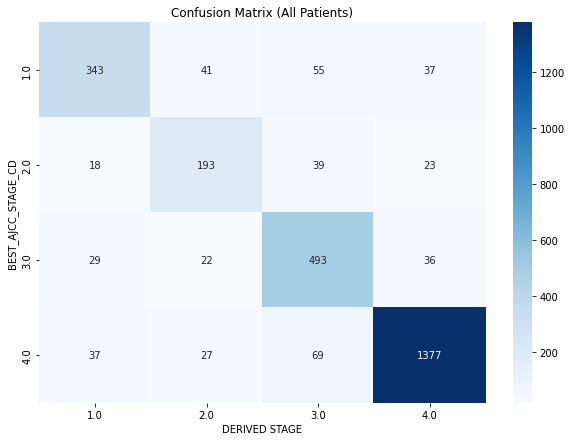

Classification Report (All Patients):
               precision    recall  f1-score   support

         1.0       0.80      0.72      0.76       476
         2.0       0.68      0.71      0.69       273
         3.0       0.75      0.85      0.80       580
         4.0       0.93      0.91      0.92      1510

    accuracy                           0.85      2839
   macro avg       0.79      0.80      0.79      2839
weighted avg       0.85      0.85      0.85      2839



In [29]:
# Generate confusion matrix and classification report for common keys
common_keys = sorted(set(ground_truth_filtered_mapping.keys()) & set(mapping_filtered_dict.keys()))
y_true_flat = np.ravel([ground_truth_filtered_mapping[key] for key in common_keys])
y_pred_flat = np.ravel([mapping_filtered_dict[key] for key in common_keys])

generate_confusion_matrix_and_report(y_true_flat, y_pred_flat, 'All Patients')

#### Those with genomics

In genomic specimen but not in derived: n=3362
In derived but not in genomic specimen: n=12585
In both derived and genomic specimen: n=3485


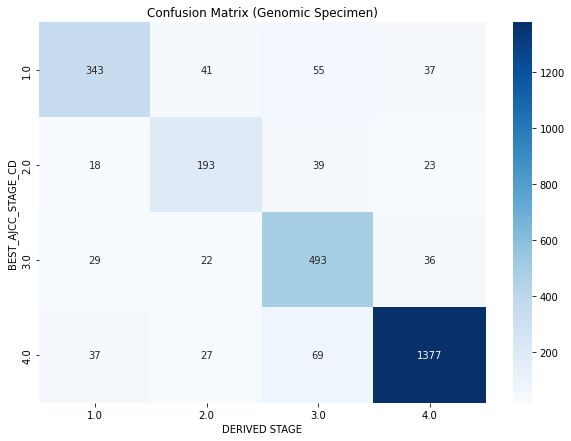

Classification Report (Genomic Specimen):
               precision    recall  f1-score   support

         1.0       0.80      0.72      0.76       476
         2.0       0.68      0.71      0.69       273
         3.0       0.75      0.85      0.80       580
         4.0       0.93      0.91      0.92      1510

    accuracy                           0.85      2839
   macro avg       0.79      0.80      0.79      2839
weighted avg       0.85      0.85      0.85      2839



In [30]:
# Filter the genomic_specimen_df for relevant MRNs
genomic_specimen_mrns = set(genomic_specimen_df['DFCI_MRN'])

# Calculate key differences for genomic specimen MRNs
calculate_key_differences(mapping_dict, ground_truth_filtered_mapping, 'genomic specimen')

# Generate confusion matrix and classification report for genomic specimen MRNs
common_keys_genomic = sorted(genomic_specimen_mrns & set(ground_truth_filtered_mapping.keys()) & set(mapping_filtered_dict.keys()))
y_true_flat_genomic = np.ravel([ground_truth_filtered_mapping[key] for key in common_keys_genomic])
y_pred_flat_genomic = np.ravel([mapping_filtered_dict[key] for key in common_keys_genomic])

generate_confusion_matrix_and_report(y_true_flat_genomic, y_pred_flat_genomic, 'Genomic Specimen')

#### Lung cancer

In registry but not in derived: n=839
In derived but not in registry: n=1386
In both derived and registry: n=751


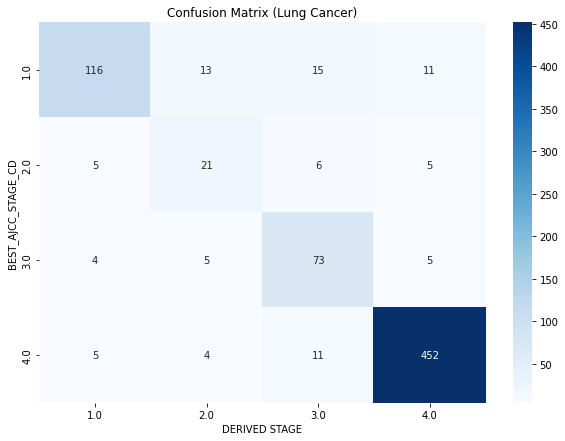

Classification Report (Lung Cancer):
               precision    recall  f1-score   support

         1.0       0.89      0.75      0.81       155
         2.0       0.49      0.57      0.53        37
         3.0       0.70      0.84      0.76        87
         4.0       0.96      0.96      0.96       472

    accuracy                           0.88       751
   macro avg       0.76      0.78      0.76       751
weighted avg       0.89      0.88      0.88       751



In [31]:
# Evaluate for Lung Cancer types
lung_cancer_types = ["Lung Adenocarcinoma", "Non-Small Cell Lung Cancer"]
common_keys_cancer, mismatch_dict = filter_and_evaluate_cancer_type(
    lung_cancer_types, genomic_specimen_df, ground_truth_filtered_mapping, mapping_filtered_dict, 'Lung Cancer')

#### Breast cancer

In registry but not in derived: n=132
In derived but not in registry: n=877
In both derived and registry: n=103


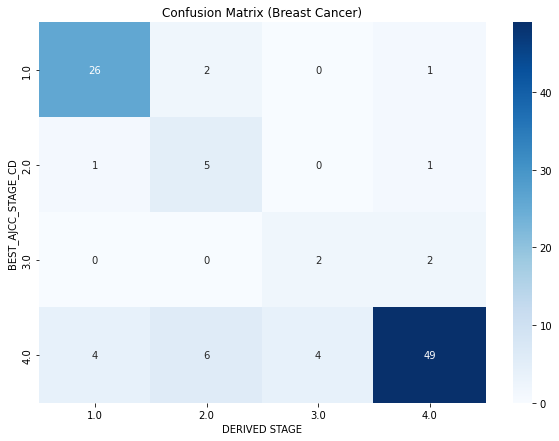

Classification Report (Breast Cancer):
               precision    recall  f1-score   support

         1.0       0.84      0.90      0.87        29
         2.0       0.38      0.71      0.50         7
         3.0       0.33      0.50      0.40         4
         4.0       0.92      0.78      0.84        63

    accuracy                           0.80       103
   macro avg       0.62      0.72      0.65       103
weighted avg       0.84      0.80      0.81       103



In [32]:
# Evaluate for Breast Cancer types
breast_cancer_types = [
    "Invasive Breast Carcinoma", "Breast Invasive Lobular Carcinoma", "Breast Invasive Ductal Carcinoma",
    "Breast Invasive Cancer, NOS", "Breast Mixed Ductal and Lobular Carcinoma", "Malignant Phyllodes Tumor of the Breast",
    "Metaplastic Breast Cancer", "Inflammatory Breast Cancer", "Adenomyoepithelioma of the Breast",
    "Breast Ductal Carcinoma In Situ", "Breast Invasive Mixed Mucinous Carcinoma", "Breast Sarcoma",
    "Solid Papillary Carcinoma of the Breast", "Mixed Type Metaplastic Breast Cancer", 
    "Breast Carcinoma with Signet Ring", "Breast Angiosarcoma", "Breast Invasive Carcinosarcoma, NOS",
    "Adenoid Cystic Breast Cancer"
]
common_keys_cancer, mismatch_dict = filter_and_evaluate_cancer_type(
    breast_cancer_types, genomic_specimen_df, ground_truth_filtered_mapping, mapping_filtered_dict, 'Breast Cancer')


#### Merge Stage 3 and 4 into Stage 3_4

In [33]:
# Apply the stage mapping (merge stages 3 and 4)
ground_truth_filtered_mapping_grouped = {key: map_stages(stage) for key, stage in ground_truth_filtered_mapping.items()}
mapping_dict_grouped = {key: map_stages(stage) for key, stage in mapping_filtered_dict.items()}

In registry but not in derived: n=839
In derived but not in registry: n=1386
In both derived and registry: n=751


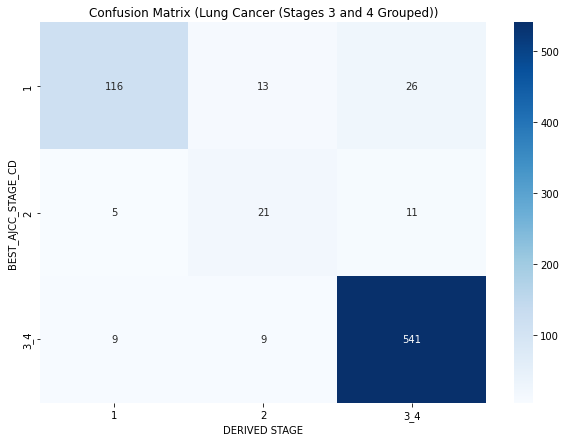

Classification Report (Lung Cancer (Stages 3 and 4 Grouped)):
               precision    recall  f1-score   support

           1       0.89      0.75      0.81       155
           2       0.49      0.57      0.53        37
         3_4       0.94      0.97      0.95       559

    accuracy                           0.90       751
   macro avg       0.77      0.76      0.76       751
weighted avg       0.90      0.90      0.90       751



In [34]:
# Evaluate for Lung Cancer types with grouped stages
common_keys_lung, mismatch_dict_lung = filter_and_evaluate_cancer_type(
    lung_cancer_types, genomic_specimen_df, ground_truth_filtered_mapping_grouped, mapping_dict_grouped, 'Lung Cancer (Stages 3 and 4 Grouped)')

In registry but not in derived: n=132
In derived but not in registry: n=877
In both derived and registry: n=103


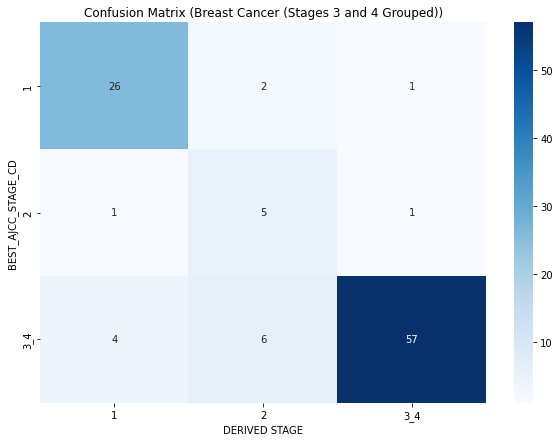

Classification Report (Breast Cancer (Stages 3 and 4 Grouped)):
               precision    recall  f1-score   support

           1       0.84      0.90      0.87        29
           2       0.38      0.71      0.50         7
         3_4       0.97      0.85      0.90        67

    accuracy                           0.85       103
   macro avg       0.73      0.82      0.76       103
weighted avg       0.89      0.85      0.87       103



In [35]:
# Evaluate for Breast Cancer types with grouped stages
common_keys_breast, mismatch_dict_breast = filter_and_evaluate_cancer_type(
    breast_cancer_types, genomic_specimen_df, ground_truth_filtered_mapping_grouped, mapping_dict_grouped, 'Breast Cancer (Stages 3 and 4 Grouped)')

### Misclassified case studies

#### Lung cancer

In [40]:
# Identify misclassified cases where true label is 1 and predicted label is 4
misclassified_mrns = mismatch_dict_lung[('1', '3_4')]

In [43]:
columns = ['DFCI_MRN', 'DIAGNOSIS_DT', 'BEST_AJCC_STAGE_CD', 'PATH_T_DESCR', 'SITE_DESCR', 'HISTOLOGY_DESCR', 'BEHAVIOR_DESCR']
misclassified_diagnosis_caref_df = diagnosis_caref_df.loc[diagnosis_caref_df.DFCI_MRN.isin(misclassified_mrns)][columns].sort_values(by='DFCI_MRN')

columns = ['DFCI_MRN', 'EVENT_DATE', 'RPT_TEXT', 'PROVIDER_DEPARTMENT', 'RPT_TYPE', 'DERIVED_STAGE_RAW', 'DERIVED_STAGE_MERGED']
misclassified_stages_df = stages_df.loc[stages_df.DFCI_MRN.isin(misclassified_mrns)][columns].sort_values(by='DFCI_MRN')

In [46]:
# Get the first 50 DFCI_MRN values
first_50_misclassified_keys = misclassified_mrns[:50]

# Loop through the first 50 DFCI_MRNs
for dfci_mrn in first_50_misclassified_keys:
    print("=" * 150)  # Separator for readability
    print(f"DFCI_MRN: {dfci_mrn}")
    print("Sequencing Info:")
    genomic_specimen_info = genomic_specimen_df.loc[genomic_specimen_df['DFCI_MRN'] == dfci_mrn]
    for _, row in genomic_specimen_info.iterrows():
        print("-" * 50)
        if not pd.isna(row['PRIMARY_CANCER_DIAGNOSIS']):
            print(f"  PRIMARY_CANCER_DIAGNOSIS: {row['PRIMARY_CANCER_DIAGNOSIS']}")
        if not pd.isna(row['TEST_ORDER_DT']):
            print(f"  TEST_ORDER_DT: {row['TEST_ORDER_DT']}")
            
    
    # Query relevant info from misclassified_diagnosis_caref_df
    diagnosis_info = misclassified_diagnosis_caref_df.loc[misclassified_diagnosis_caref_df['DFCI_MRN'] == dfci_mrn]
    print('\n')
    print("-" * 100)
    print("Diagnosis Info:")
    for _, row in diagnosis_info.iterrows():
        print("-" * 50)
        if not pd.isna(row['DIAGNOSIS_DT']):
            print(f"  DIAGNOSIS_DT: {row['DIAGNOSIS_DT']}")
        if not pd.isna(row['BEST_AJCC_STAGE_CD']):
            print(f"  BEST_AJCC_STAGE_CD: {row['BEST_AJCC_STAGE_CD']}")
        if not pd.isna(row['PATH_T_DESCR']):
            print(f"  PATH_T_DESCR: {row['PATH_T_DESCR']}")
        if not pd.isna(row['SITE_DESCR']):
            print(f"  SITE_DESCR: {row['SITE_DESCR']}")
        if not pd.isna(row['HISTOLOGY_DESCR']):
            print(f"  HISTOLOGY_DESCR: {row['HISTOLOGY_DESCR']}")
        if not pd.isna(row['BEHAVIOR_DESCR']):
            print(f"  BEHAVIOR_DESCR: {row['BEHAVIOR_DESCR']}")
    
    # Query relevant info from misclassified_stages_df
    stages_info = misclassified_stages_df.loc[misclassified_stages_df['DFCI_MRN'] == dfci_mrn]
    print('\n')
    print("-" * 100)
    print("Stages Info:")
    for _, row in stages_info.iterrows():
        print("-" * 50)
        if not pd.isna(row['EVENT_DATE']):
            print(f"  EVENT_DATE: {row['EVENT_DATE']}")
        if not pd.isna(row['DERIVED_STAGE_RAW']):
            print(f"  DERIVED_STAGE_RAW: {row['DERIVED_STAGE_RAW']}")
        if not pd.isna(row['DERIVED_STAGE_MERGED']):
            print(f"  DERIVED_STAGE_MERGED: {row['DERIVED_STAGE_MERGED']}")
        print('\n')
        if not pd.isna(row['RPT_TEXT']):
            print(f"  RPT_TEXT: {row['RPT_TEXT']}")
        print('\n')
        if not pd.isna(row['PROVIDER_DEPARTMENT']):
            print(f"  PROVIDER_DEPARTMENT: {row['PROVIDER_DEPARTMENT']}")

        if not pd.isna(row['RPT_TYPE']):
            print(f"  RPT_TYPE: {row['RPT_TYPE']}")
        print('\n')
    
    print("=" * 150)  # Separator for readability


DFCI_MRN: 204307
Sequencing Info:
--------------------------------------------------
  PRIMARY_CANCER_DIAGNOSIS: Lung Adenocarcinoma
  TEST_ORDER_DT: 2017-09-06


----------------------------------------------------------------------------------------------------
Diagnosis Info:
--------------------------------------------------
  DIAGNOSIS_DT: 2017-07-28
  BEST_AJCC_STAGE_CD: 1A
  PATH_T_DESCR: TUMOR > 2 CM BUT <=3 CM IN GREATEST DIMENSION
  SITE_DESCR: LUNG, UPPER LOBE
  HISTOLOGY_DESCR: ADENOCARCINOMA WITH MIXED SUBTYPES
  BEHAVIOR_DESCR: MALIGNANT, PRIMARY


----------------------------------------------------------------------------------------------------
Stages Info:
--------------------------------------------------
  EVENT_DATE: 2017-08-21
  DERIVED_STAGE_RAW: 3
  DERIVED_STAGE_MERGED: 3.0


  RPT_TEXT:  who is seen in consultation for evaluation of a left upper lobe nodule. The patient has history of stage III invasive ductal carcinoma of the right breast, which was initially